# Tugas 2 - Klasifikasi Diabetes dengan Naive Bayes dan Logistic Regression

| Nama | NRP |
|------|-----|
|Jonathan Joyo Wibowo|5054251026|

## Deskripsi Tugas
Pada tugas ini, kita akan menggunakan Pima Indians Diabetes Dataset. Dataset bisa diakses melalui link berikut:\
https://www.kaggle.com/datasets/jamaltariqcheema/pima-indians-diabetes-dataset

Tujuan utama dari tugas ini adalah membangun model Naive Bayes dan Logistic Regression untuk mengklasifikasikan apakah seorang pasien menderita diabetes atau tidak.

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset dan Eksplorasi Awal
   - Memuat dataset, melihat struktur data, dan distribusi label.
2. Preprocessing
   - Memproses data agar siap digunakan dalam membangun model.
3. Eksperimen Model
   - Bangun model Gaussian Naive Bayes dan Logistic Regression.
4. Evaluasi Model
   - Hitung metrik evaluasi dan visualisasikan hasilnya.
5. Analisis dan Kesimpulan
   - Bandingkan hasil kedua model dan berikan kesimpulan.

# 1. Persiapan Dataset dan Eksplorasi Awal

In [231]:
# Import library yang dibutuhkan (pandas, numpy, matplotlib, seaborn, sklearn, dll)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive

from sklearn.compose import ColumnTransformer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, LabelBinarizer, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix, auc, roc_curve

from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression

SEED = 67

In [232]:
# Mount drive ke filesystem vm google collab, soalnya dataset di gdrive
uploaded = drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [233]:
pd.set_option('display.width', 1000)
pd.set_option('display.max_columns', None)
np.set_printoptions(suppress=True)

In [234]:
# Load dataset dan tampilkan informasi dasar: jumlah baris dan kolom, tipe data, statistik deskriptif, dan jumlah missing value.
data = pd.read_csv("/content/drive/MyDrive/dataset/pima_indians_diabetes/diabetes.csv")
data.head(30)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72.0,35,169.5,33.6,0.627,50,1
1,1,85,66.0,29,102.5,26.6,0.351,31,0
2,8,183,64.0,32,169.5,23.3,0.672,32,1
3,1,89,66.0,23,94.0,28.1,0.167,21,0
4,0,137,40.0,35,168.0,43.1,2.288,33,1
5,5,116,74.0,27,102.5,25.6,0.201,30,0
6,3,78,50.0,32,88.0,31.0,0.248,26,1
7,10,115,70.0,27,102.5,35.3,0.134,29,0
8,2,197,70.0,45,543.0,30.5,0.158,53,1
9,8,125,96.0,32,169.5,34.3,0.232,54,1


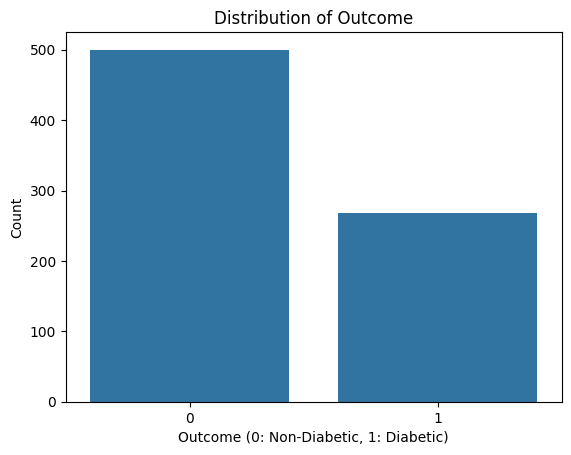

In [235]:
# Tampilkan distribusi kelas target (Outcome) dalam bentuk bar plot.
# Perhatikan apakah dataset ini imbalanced.
sns.countplot(x="Outcome", data=data)
plt.xlabel("Outcome (0: Non-Diabetic, 1: Diabetic)")
plt.ylabel("Count")
plt.title("Distribution of Outcome")
plt.show()

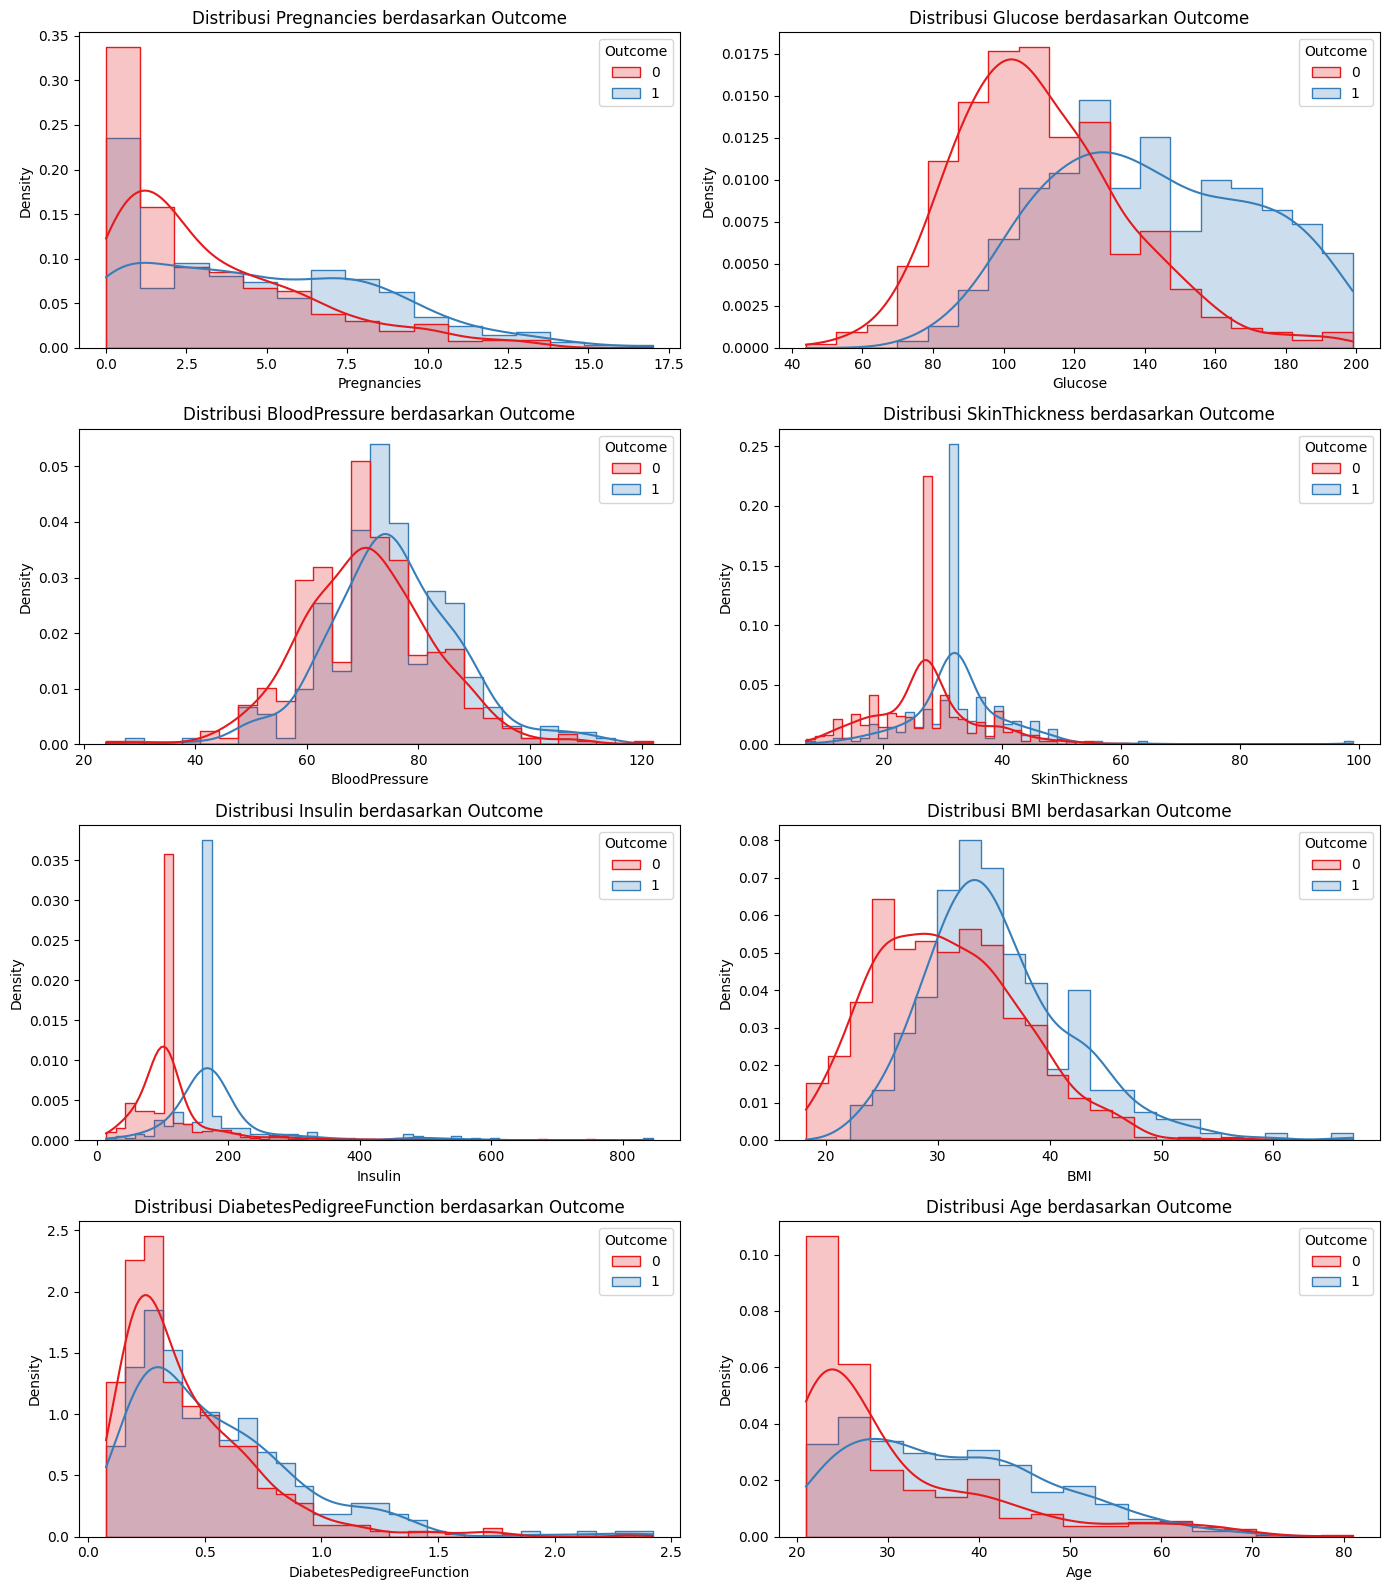

In [236]:
# Tampilkan distribusi setiap fitur menggunakan histogram atau KDE plot, dibedakan berdasarkan kelas Outcome.
# Ambil daftar fitur (semua kolom kecuali target Outcome)
features = [col for col in data.columns if col != "Outcome"]

# Buat subplot grid (4 baris x 2 kolom)
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(14, 16))
axes = axes.flatten()

# Plot distribusi untuk setiap fitur
for idx, col in enumerate(features):
    sns.histplot(
        data=data,
        x=col,
        hue="Outcome",
        kde=True,
        element="step",
        stat="density",
        common_norm=False,
        palette="Set1",
        ax=axes[idx],
    )
    axes[idx].set_title(f"Distribusi {col} berdasarkan Outcome", fontsize=12)
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel("Density")

plt.tight_layout()
plt.show()

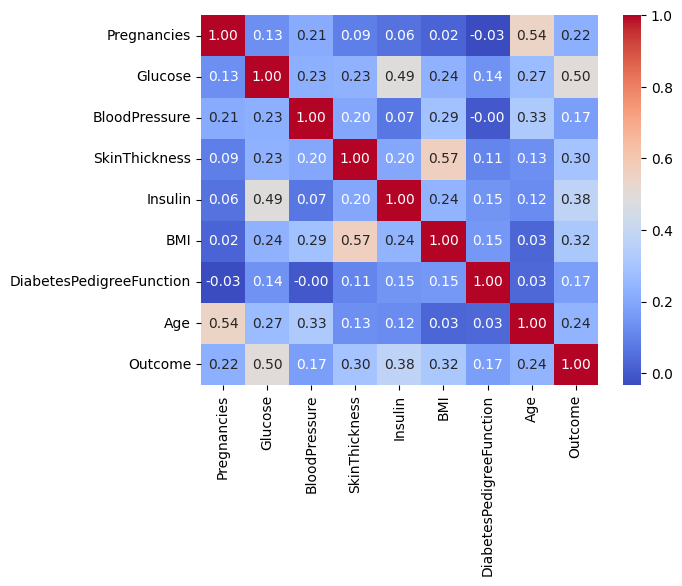

In [237]:
# Tampilkan heatmap korelasi antar fitur.
corr_matrix = data.corr()
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.show()

In [238]:
print("Data Shape: ")
print(data.shape)

print("\nData Info: ")
print(data.info())

print("\nData Describe: ")
print(data.describe())

Data Shape: 
(768, 9)

Data Info: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    float64
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    float64
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(4), int64(5)
memory usage: 54.1 KB
None

Data Describe: 
       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin         BMI  DiabetesPedigreeFunction         Age     Outcome
count   768.000000  768.000000     768.000000   

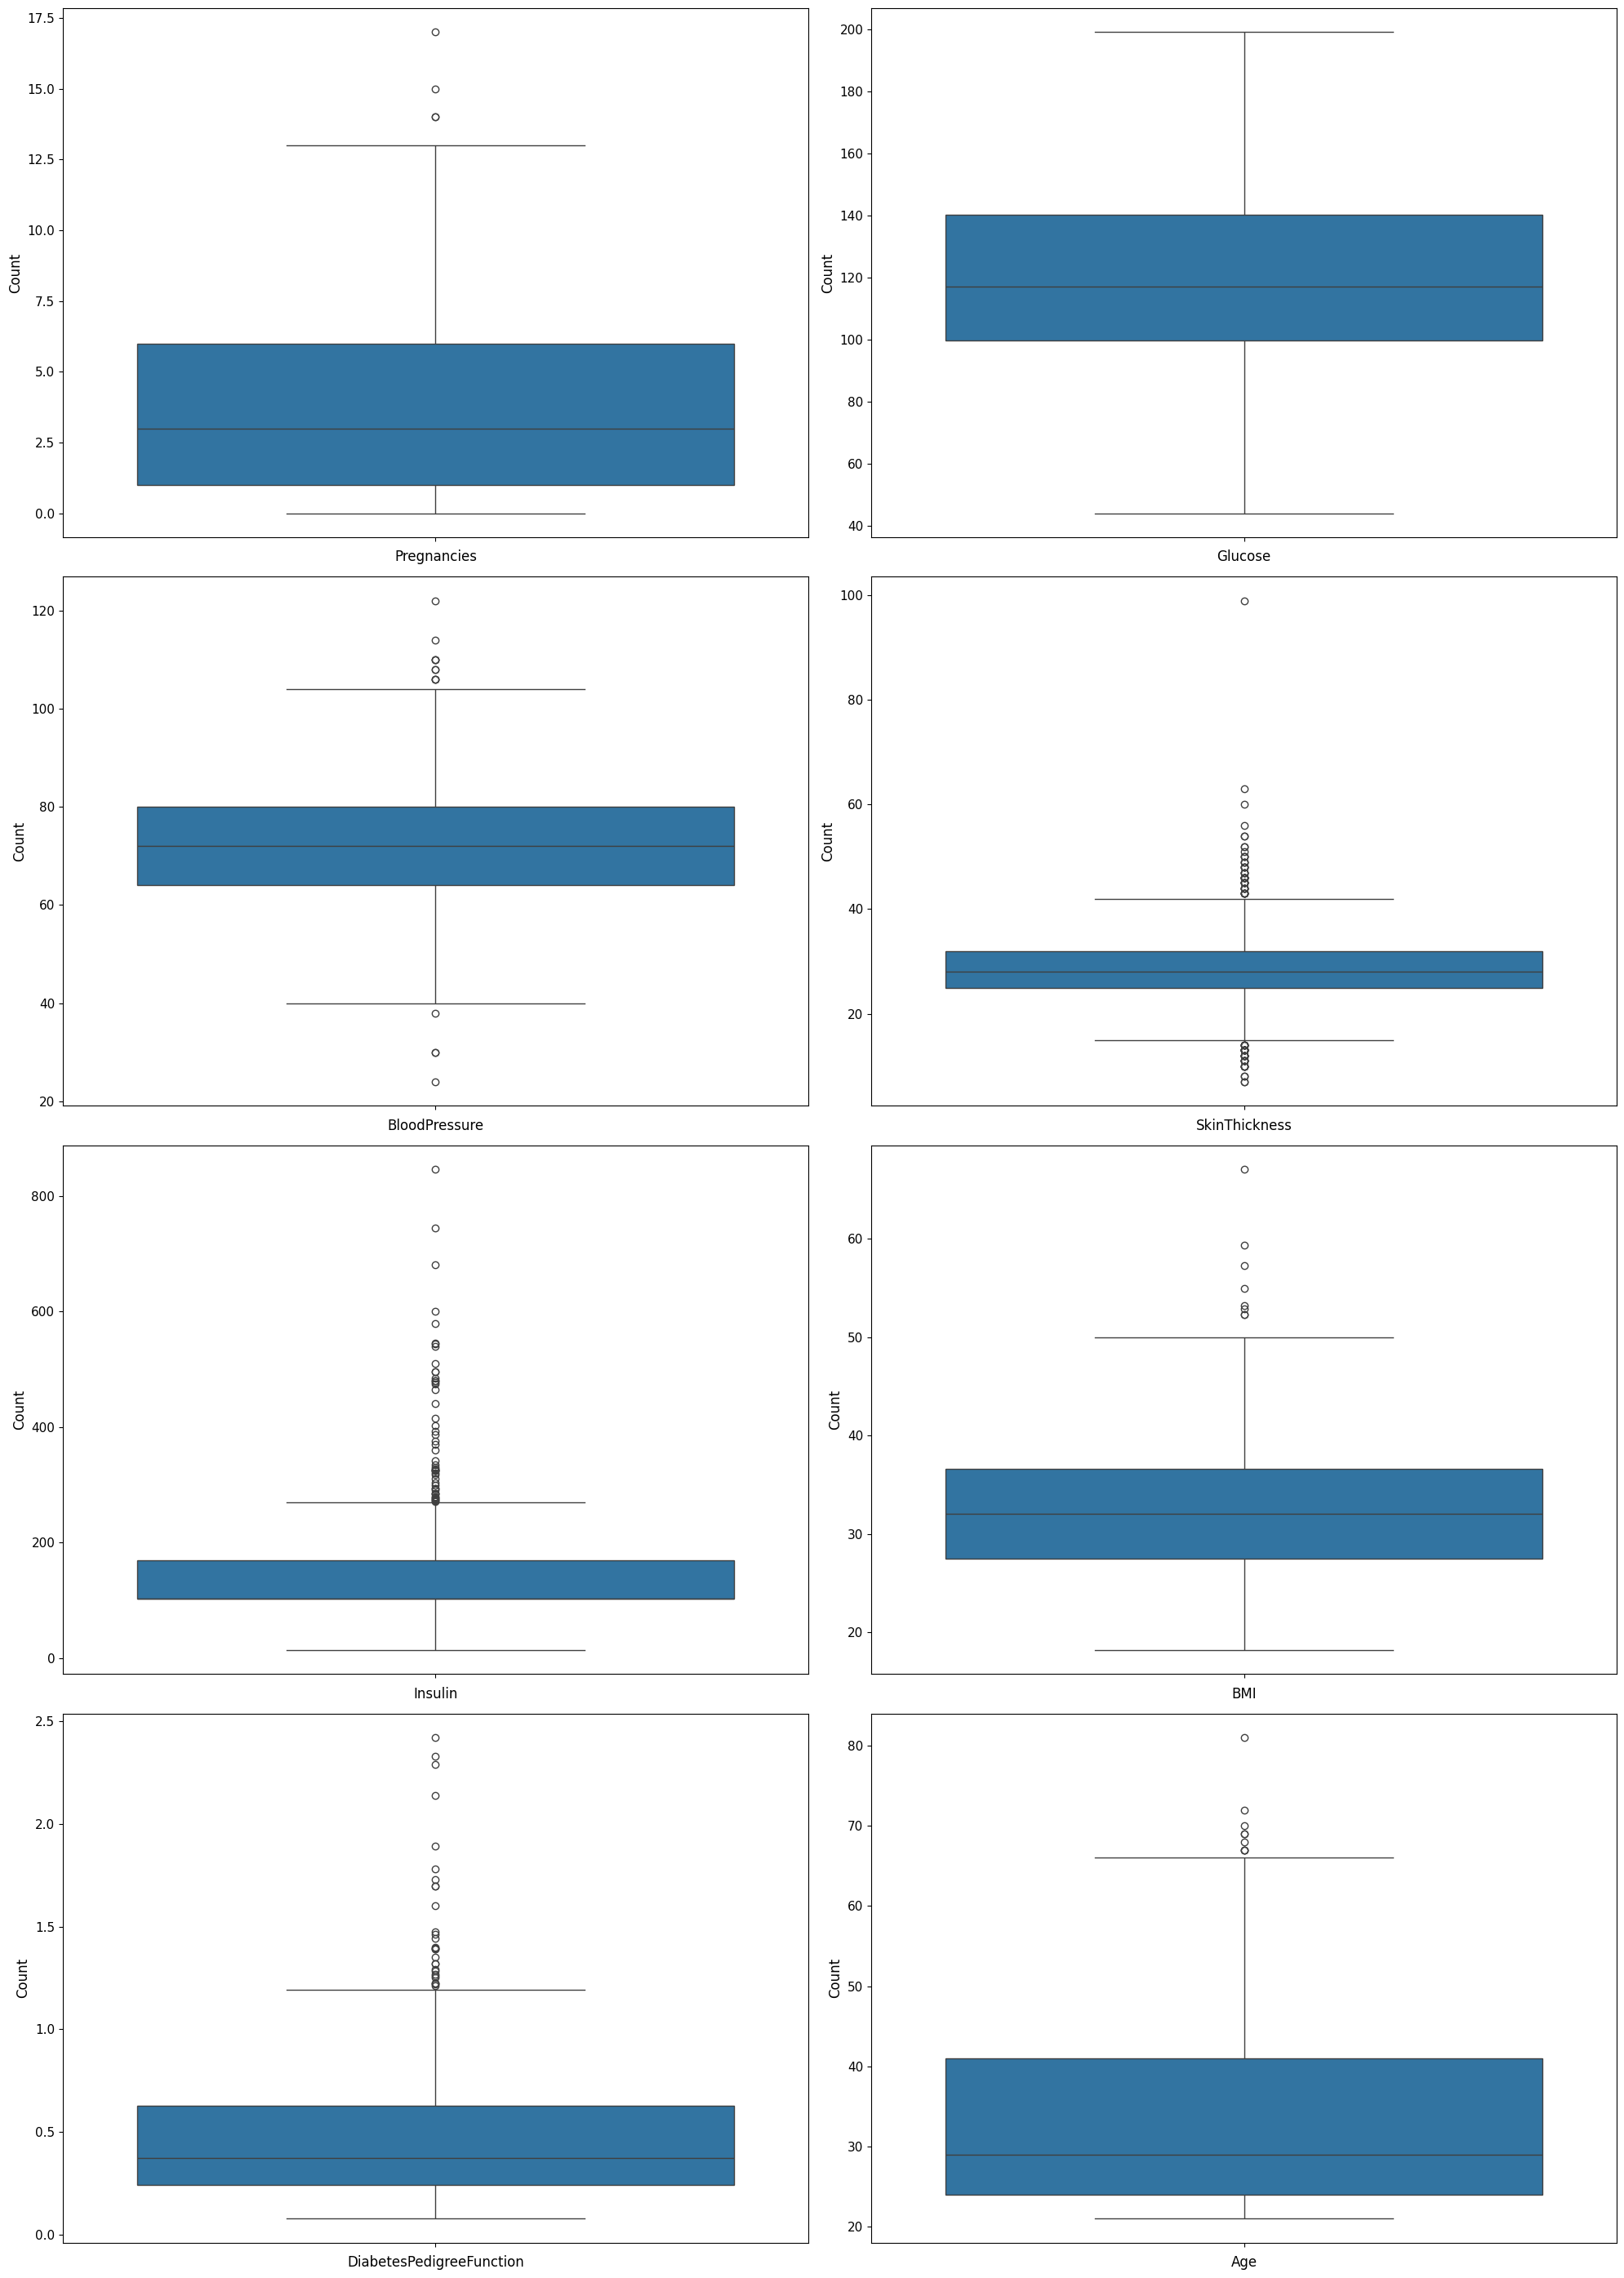

In [239]:
features = [col for col in data.columns if col != "Outcome"]
row, col = 4, 2

fig, axes = plt.subplots(nrows=row, ncols=col, figsize=(col * 10, row * 7))
axes = axes.flatten()

for i, column in enumerate(features):
  sns.boxplot(y=column, data=data, ax=axes[i])
  axes[i].set_xlabel(column, fontsize=12)
  axes[i].set_ylabel("Count", fontsize=12)
  axes[i].tick_params(axis="both", labelsize=11)

for j in range(len(features), len(axes)):
  fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## Lakukan Exploratory Data Analysis (EDA) tambahan yang diperlukan.

# 2. Preprocessing

In [240]:
# Beberapa kolom seperti Glucose, BloodPressure, SkinThickness, Insulin, dan BMI memiliki nilai 0 yang secara medis tidak mungkin.
# Identifikasi kolom-kolom tersebut dan hitung jumlah nilai 0 pada masing-masing kolom.

zero_cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
(data[zero_cols] == 0).sum()

,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0


In [241]:
# Tangani nilai 0 tersebut dengan strategi yang sesuai (misalnya imputasi dengan median atau mean).
# Pastikan strategi yang dipilih tidak memperkenalkan data leakage.

In [242]:
# Pisahkan fitur (X) dan target (y).
# Bagi data menjadi train set dan test set (misalnya 80:20).
# Gunakan stratify=y agar distribusi kelas tetap proporsional.
split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
train_data, test_data = None, None

for train_idx, test_idx in split.split(data, data["Outcome"]):
  train_data, test_data = data.iloc[train_idx], data.iloc[test_idx]

x_train, y_train = train_data.drop(columns=["Outcome"], axis=1), train_data["Outcome"]
x_test, y_test = test_data.drop(columns=["Outcome"], axis=1), test_data["Outcome"]

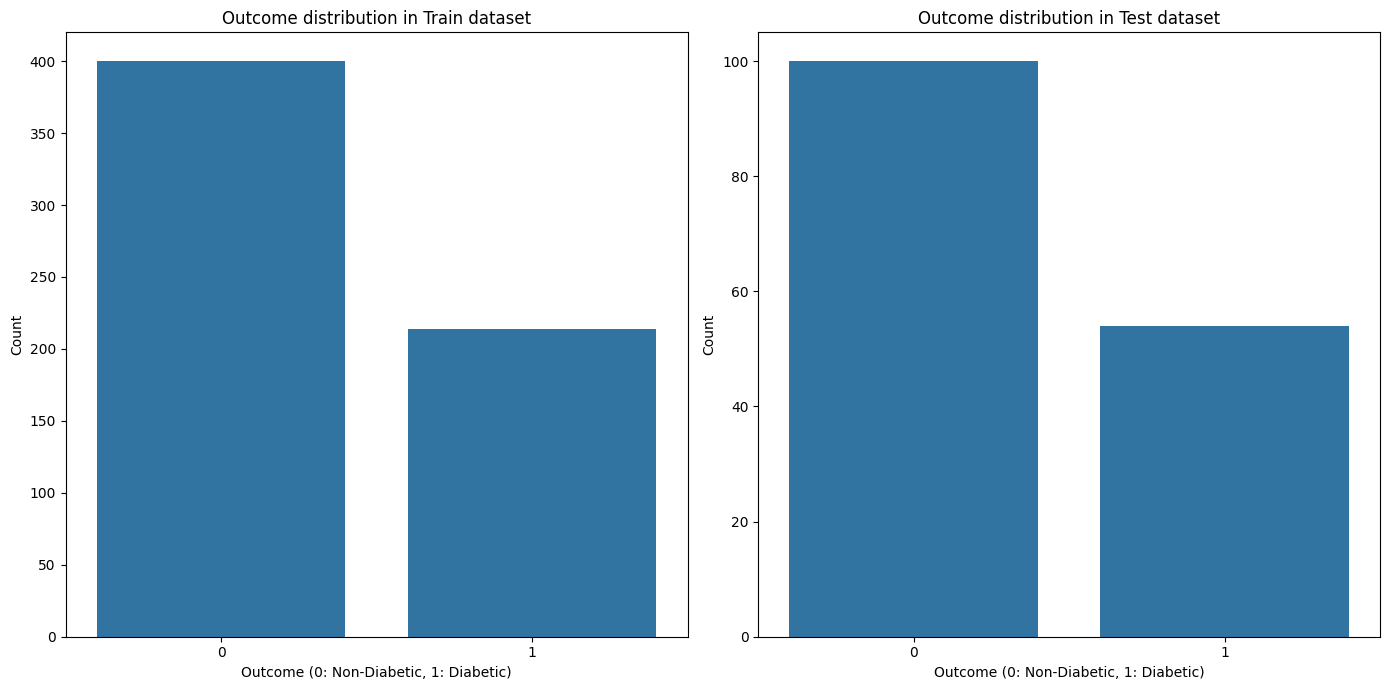

In [243]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 7))
axes = axes.flatten()

sns.countplot(x="Outcome", data=pd.DataFrame(y_train), ax=axes[0])
axes[0].set_title("Outcome distribution in Train dataset")
axes[0].set_xlabel("Outcome (0: Non-Diabetic, 1: Diabetic)")
axes[0].set_ylabel("Count")

sns.countplot(x="Outcome", data=pd.DataFrame(y_test), ax=axes[1])
axes[1].set_title("Outcome distribution in Test dataset")
axes[1].set_xlabel("Outcome (0: Non-Diabetic, 1: Diabetic)")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

In [244]:
class FeatureScaler(BaseEstimator, TransformerMixin):
  def fit(self, x, y=None):
    self.standard_scaler = StandardScaler()
    self.standard_scaler.fit(x)
    return self

  def transform(self, x):
    data_copy = x.copy()
    data_copy = self.standard_scaler.transform(data_copy)
    return data_copy

In [245]:
scaling_preprocessor = Pipeline([("feature_scaler", FeatureScaler())])

In [246]:
# Lakukan feature scaling menggunakan StandardScaler.
# Fit hanya pada train set, kemudian transform pada train set dan test set.
x_gaussian_nb_train = scaling_preprocessor.fit_transform(x_train)
x_gaussian_nb_test = scaling_preprocessor.transform(x_test)
y_gaussian_nb_train = y_train.copy()
y_gaussian_nb_test = y_test.copy()

x_log_reg_train = scaling_preprocessor.fit_transform(x_train)
x_log_reg_test = scaling_preprocessor.transform(x_test)
y_log_reg_train = y_train.copy()
y_log_reg_test = y_test.copy()

/usr/local/lib/python3.13/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


# 3. Eksperimen Model

## 3.1 Gaussian Naive Bayes

Gunakan GaussianNB karena semua fitur pada dataset ini bersifat numerik kontinu.

In [247]:
# Inisialisasi dan latih model Gaussian Naive Bayes menggunakan train set.
gaussian_nb = GaussianNB()
gaussian_nb.fit(x_gaussian_nb_train, y_gaussian_nb_train)

GaussianNB()

In [248]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label dan probabilitas kelas 1 untuk keperluan evaluasi.
y_pred_gaussian_nb = gaussian_nb.predict(x_gaussian_nb_test)
y_prob_gaussian_nb = gaussian_nb.predict_proba(x_gaussian_nb_test)[:, 1]
accuracy_gaussian_nb = accuracy_score(y_gaussian_nb_test, y_pred_gaussian_nb)
accuracy_gaussian_nb

0.7402597402597403

## 3.2 Logistic Regression

In [249]:
# Inisialisasi dan latih model Logistic Regression menggunakan train set.
log_reg = LogisticRegression()
log_reg.fit(x_log_reg_train, y_log_reg_train)

LogisticRegression()

In [250]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label dan probabilitas kelas 1 untuk keperluan evaluasi.
y_pred_log_reg = log_reg.predict(x_log_reg_test)
y_prob_log_reg = log_reg.predict_proba(x_log_reg_test)[:, 1]
accuracy_log_reg = accuracy_score(y_log_reg_test, y_pred_log_reg)
accuracy_log_reg

0.7467532467532467

# 4. Evaluasi Model

In [251]:
# Tampilkan metrik evaluasi untuk setiap model: Accuracy, Precision, Recall, dan F1-Score.
models = {"Gaussian NB": (y_gaussian_nb_test, y_pred_gaussian_nb),
          "Logistic Regression": (y_log_reg_test, y_pred_log_reg)}

eval_matrices = []

for name, (y_test, y_pred) in models.items():
  eval_matrix = {
      "Model": name,
      "Accuracy": accuracy_score(y_test, y_pred),
      "Precision": precision_score(y_test, y_pred),
      "Recall": recall_score(y_test, y_pred),
      "F1-Score": f1_score(y_test, y_pred)
  }
  eval_matrices.append(eval_matrix)

eval_df = pd.DataFrame(eval_matrices)
eval_df

,Model,Accuracy,Precision,Recall,F1-Score
0,Gaussian NB,0.740260,0.640000,0.592593,0.615385
1,Logistic Regression,0.746753,0.659574,0.574074,0.613861


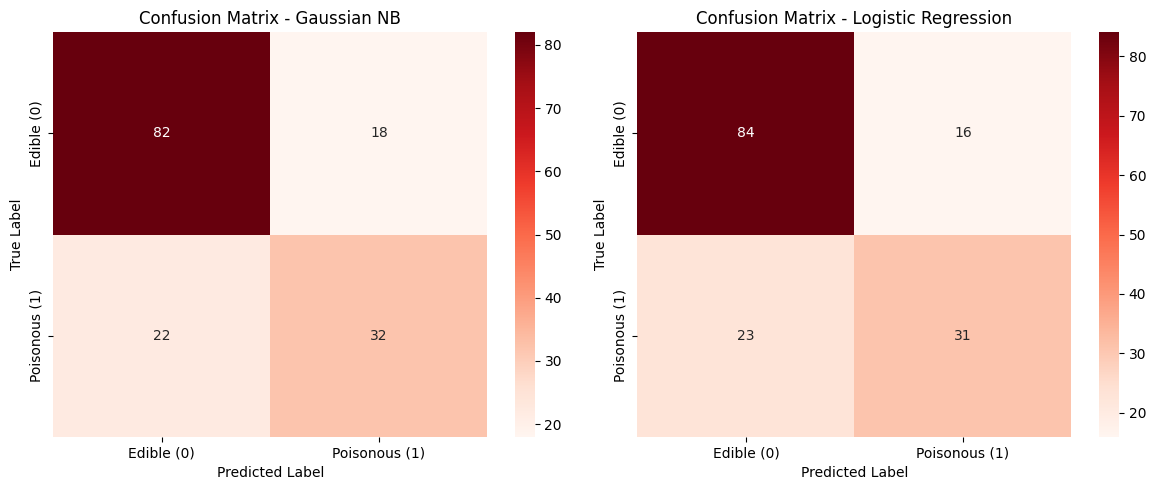

In [252]:
# Tampilkan Confusion Matrix setiap model dalam bentuk heatmap.
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (name, (y_true, y_pred)) in zip(axes, models.items()):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Reds",
        ax=ax,
        xticklabels=["Edible (0)", "Poisonous (1)"],
        yticklabels=["Edible (0)", "Poisonous (1)"],
    )
    ax.set_title(f"Confusion Matrix - {name}")
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("True Label")

plt.tight_layout()
plt.show()

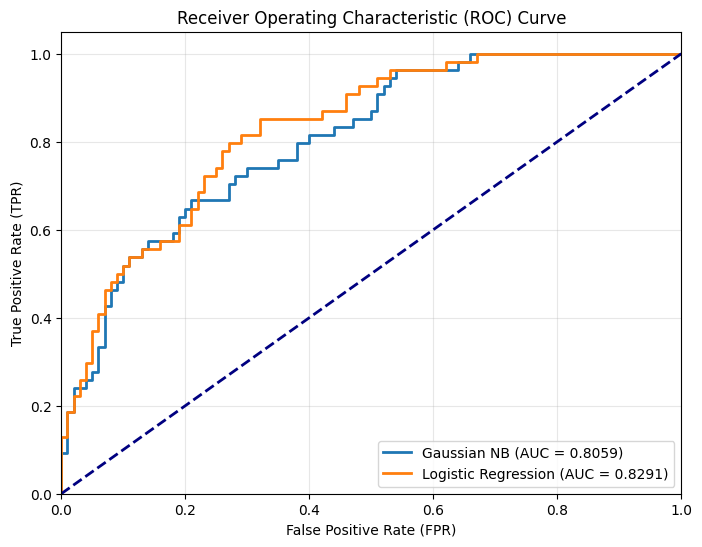

In [253]:
# Tampilkan ROC Curve kedua model dalam satu plot beserta nilai AUC masing-masing.
probas = {
    "Gaussian NB": (y_gaussian_nb_test, y_prob_gaussian_nb),
    "Logistic Regression": (y_log_reg_test, y_prob_log_reg),
}

plt.figure(figsize=(8, 6))

for name, (y_true, y_prob) in probas.items():
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f"{name} (AUC = {roc_auc:.4f})")

plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

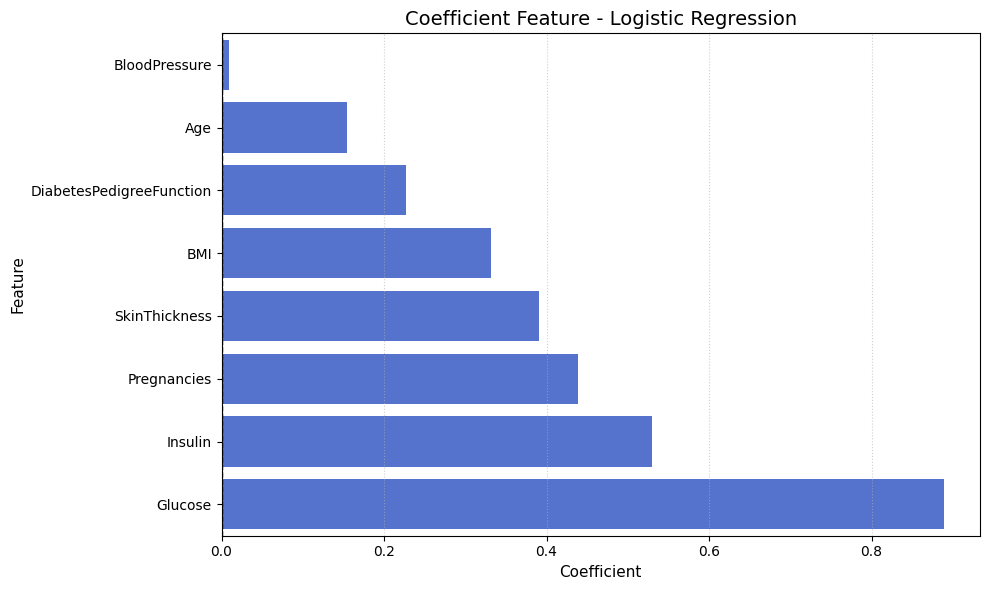

In [259]:
# Khusus Logistic Regression: tampilkan koefisien setiap fitur dalam bentuk bar chart horizontal.
# Koefisien positif menandakan fitur meningkatkan probabilitas diabetes, negatif sebaliknya.
coefficients = log_reg.coef_[0]

coef_df = pd.DataFrame({
    "Feature": features,
    "Coefficient": coefficients
}).sort_values(by="Coefficient", ascending=True)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=coef_df,
    x="Coefficient",
    y="Feature",
    hue="Feature",
    palette=["crimson" if c < 0 else "royalblue" for c in coef_df["Coefficient"]])

plt.axvline(0, color="black", linestyle="--", linewidth=1)
plt.title("Coefficient Feature - Logistic Regression", fontsize=14)
plt.xlabel("Coefficient", fontsize=11)
plt.ylabel("Feature", fontsize=11)
plt.grid(axis="x", linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()

# 5. Analisis

#### Model Gaussian Bayes dan Logistic Regression cukup bagus dalam memprediksi apakah seseorang diabetes atau tidak berdasarkan dataset

#### Meskipun Accuracy mencapai kisaran \~74.6%, poin Recall masih tergolong rendah (\~57%–59%). Hal ini berarti bahwa model masih melewatkan sekitar 40% pasien yang sebenarnya menderita diabetes (False Negative).


#### Kedua Model memberikan hasil yang cukup sama, namun jika dilihat dari ROC Curve, maka Logistic Regression sedikit lebih unggul

#### Jika dilihat dari Grafik Fitur Koefisien, bisa dilihat bahwa fitur yang paling berpengaruh terhadap diabetes adalah Glucose

# 6. Kesimpulan dan Saran

### Logistic Regression sedikit lebih unggul dalam memprediksi penyakit diabetes, sedangkan fitur yang paling berpengaruh adalah Glucose atau kadar gula darah

### Untuk saran mungkin selanjutnya bisa dicari cara untuk menangani class imbalance